In [ ]:
# 导入必要的库
import gymnasium as gym
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import random
import torch
from torch import nn
import torch.nn.functional as F
import argparse
import itertools
import os
from collections import deque
import random
import os
from IPython.display import HTML
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import torch
import gymnasium as gym

In [ ]:
# 1.设置Matplotlib后端和设备

# 用于保存训练信息的目录
RUNS_DIR = "runs"
# 创建保存训练结果的文件夹，若文件夹已存在则不进行操作
os.makedirs(RUNS_DIR, exist_ok=True)
# 选择设备（GPU或CPU），优先使用GPU，如果没有GPU则使用CPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'


## 完成此处代码

In [ ]:
# 2.深度Q网络的实现

class DQN(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=256, enable_dueling_dqn=True):
        super(DQN, self).__init__()
        # 是否启用双重DQN（Dueling DQN）
        self.enable_dueling_dqn = enable_dueling_dqn
        # 定义第一层全连接层，输入维度是状态空间的维度，输出维度是隐藏层的大小
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        if self.enable_dueling_dqn:
            # 如果启用双重DQN，则使用两个流来计算Q值：价值流和优势流
            self.fc_value = nn.Linear(hidden_dim, 256)  # 全连接层
            self.value = nn.Linear(256, 1)  # 输出状态的价值V(s)
            self.fc_advantages = nn.Linear(hidden_dim, 256)  # 全连接层
            self.advantages = nn.Linear(256, action_dim)  # 输出每个动作的优势A(s, a)
        else:
            # 如果不启用双重DQN，则只有一个输出层来计算Q值
            self.output = nn.Linear(hidden_dim, action_dim)  # 输出Q值，维度与动作空间一致
    def forward(self, x):
        # 前向传播：输入x是当前状态的特征，进行一系列计算并输出Q值
        x = F.relu(self.fc1(x))  # 使用ReLU激活函数
        if self.enable_dueling_dqn:

            # 如果启用双重DQN，则计算价值V(s)和优势A(s, a)
            # 计算状态的价值V(s)
            value = F.relu(self.fc_value(x))
            value = self.value(value)
             # 通过fc_value计算
             # 输出最终的状态价值V(s)
            # 计算动作的优势A(s, a)
            advantages = F.relu(self.fc_advantages(x))
            advantages = self.advantages(advantages)
           # 通过fc_advantages计算
            # 输出每个动作的优势A(s, a)
            # 根据V(s)和A(s, a)计算Q值
            Q = value + advantages - advantages.mean(dim=1, keepdim=True)

        else:
            # 如果没有启用双重DQN，则直接输出Q值
            Q = self.output(x)  # 直接使用全连接层输出Q值
        return Q  # 返回Q值

In [ ]:
# 3.定义经验回放类（ReplayMemory）

class ReplayMemory():
    # 初始化函数，maxlen为内存的最大容量，seed为随机种子（可选）
    def __init__(self, maxlen, seed=None):
        # 使用 deque 来存储经验回放数据，deque 是一个高效的双端队列，可以方便地从两端插入和删除元素。
        # maxlen 参数限制了队列的最大长度，超出最大长度时会自动丢弃最旧的元素。
        self.memory = deque([], maxlen=maxlen)
        # 如果提供了随机种子，则设置随机种子，保证结果可复现
        if seed is not None:
            random.seed(seed)
    # 添加一个新的经验（transition）到回放内存中
    def append(self, transition):
        # transition 是一个包含状态、动作、奖励等信息的元组
        self.memory.append(transition)
    # 从回放内存中随机抽取一个样本，返回的是一个包含 transition 的列表
    def sample(self, sample_size):
        # 使用 random.sample() 从 memory 中随机选取 sample_size 个样本
        return random.sample(self.memory, sample_size)
    # 返回当前回放内存中存储的经验数量
    def __len__(self):
        return len(self.memory)

## 完成此处代码

In [ ]:
# 4.定义深度Q学习智能体类（Agent）

class Agent():
    # 初始化方法，设置超参数
    def __init__(self, hyperparameter_set):
        self.hyperparameter_set = hyperparameter_set
        # 直接设置相关超参数值
        self.env_id = 'CartPole-v1'  # 环境ID
        self.learning_rate_a = 0.001  # 学习率（alpha）
        self.discount_factor_g = 0.99  # 折扣因子（gamma）
        self.network_sync_rate = 100  # 策略网络和目标网络同步的步数
        self.replay_memory_size = 100000  # 回放内存的大小
        self.mini_batch_size = 64  # 每次训练时从回放内存中抽取的样本数
        self.epsilon_init = 1  # 初始的epsilon值，表示随机行动的概率
        self.epsilon_decay = 0.9995  # epsilon衰减的速率
        self.epsilon_min = 0.01  # 最小的epsilon值
        self.stop_on_reward = 100000  # 达到此奖励后停止训练
        self.fc1_nodes = 128  # 神经网络隐藏层的节点数
        self.env_make_params = {}  # 环境的特定参数（空字典）
        self.enable_double_dqn = True  # 是否启用Double DQN
        self.enable_dueling_dqn = False  # 是否启用Dueling DQN（根据需求修改为True/False）
        self.max_training_episodes=8000 # 最大训练轮次，可以调整
        # 神经网络的损失函数：均方误差
        self.loss_fn = nn.MSELoss()
        # 神经网络的优化器，稍后初始化
        self.optimizer = None
        self.render = False
        self.env=gym.make(self.env_id, render_mode='human' if self.render else None, **self.env_make_params)
        # DQN模型
        self.dqn = DQN(self.env.observation_space.shape[0], self.env.action_space.n, self.fc1_nodes, self.enable_dueling_dqn).to(device)
        # 模型文件路径
        self.MODEL_FILE = os.path.join(RUNS_DIR, f'{self.hyperparameter_set}.pt')
        # 图像文件路径
        self.GRAPH_FILE = os.path.join(RUNS_DIR, f'{self.hyperparameter_set}.png')
    # 训练过程，is_training为True表示训练，render表示是否渲染环境
    def run(self, is_training=True, render=False):
        if is_training:
            print("Training starting...")
        # 创建环境实例
        # env = gym.make(self.env_id, render_mode='human' if render else None, **self.env_make_params)
        env = self.env
        # 获取可能的动作数
        num_actions = env.action_space.n
        # 获取状态空间的大小
        num_states = env.observation_space.shape[0]  # 假设状态空间为一个向量，维度为状态数
        # 用来记录每个回合的奖励
        rewards_per_episode = []
        # 创建策略网络和目标网络，隐藏层的节点数可以调整
        # policy_dqn = DQN(num_states, num_actions, self.fc1_nodes, self.enable_dueling_dqn).to(device)
        policy_dqn = self.dqn
        if is_training:
            # 初始化epsilon值
            epsilon = self.epsilon_init
            # 初始化回放内存
            memory = ReplayMemory(self.replay_memory_size)
            # 创建目标网络，并使其与策略网络相同
            target_dqn = DQN(num_states, num_actions, self.fc1_nodes, self.enable_dueling_dqn).to(device)
            target_dqn.load_state_dict(policy_dqn.state_dict())
            # 初始化优化器（Adam优化器）
            self.optimizer = torch.optim.Adam(policy_dqn.parameters(), lr=self.learning_rate_a)
            # 用来记录epsilon值的衰减过程
            epsilon_history = []
            # 跟踪已执行的步数，用于同步策略网络和目标网络
            step_count = 0
            # 跟踪历史最好的奖励
            best_reward = -9999999
        else:
            # 加载训练好的策略网络
            policy_dqn.load_state_dict(torch.load(self.MODEL_FILE))
            # 切换为评估模式
            policy_dqn.eval()
        for episode in range(self.max_training_episodes+1):
            # 初始化环境，获取初始状态
            state, _ = env.reset()  # 返回值为(state, info)
            state = torch.tensor(state, dtype=torch.float, device=device)  # 将状态转为Tensor，并放到指定设备上
            terminated = False  # 终止标志，True表示智能体到达目标或失败
            episode_reward = 0.0  # 用于累计每个回合的奖励
            # 在回合内进行动作直到终止或达到最大奖励
            done = False
            while not done and episode_reward < self.stop_on_reward:
                # epsilon-greedy 策略：以epsilon的概率选择随机动作，以1-epsilon的概率选择最优动作
                if is_training and random.random() < epsilon:
                    # 选择随机动作
                    ####补充完成
                    action = torch.tensor(env.action_space.sample(), device=device)

                else:
                    # 选择最优动作
                    with torch.no_grad():
                        ####补充完成
                        action = policy_dqn(state.unsqueeze(0)).argmax(dim=1).squeeze()

                # 执行动作并返回新的状态、奖励等信息
                new_state, reward, terminated, truncated, info = env.step(action.item())

                done = terminated or truncated
                # 累加奖励
                episode_reward += reward
                # 将新的状态和奖励转为Tensor并放到指定设备上
                new_state = torch.tensor(new_state, dtype=torch.float, device=device)
                reward = torch.tensor(reward, dtype=torch.float, device=device)
                if is_training:
                    # 将经验存储到回放内存中
                    memory.append((state, action, new_state, reward, terminated))

                    # 增加步数计数器
                    step_count += 1
                # 更新状态
                state = new_state
            # 记录每个回合的奖励
            rewards_per_episode.append(episode_reward)
            # 如果当前回合奖励超过历史最佳奖励，则保存模型
            if is_training:
                if episode_reward >= best_reward:
                    log_message = f"New best reward {episode_reward:0.1f} ({(episode_reward - best_reward) / best_reward * 100:+.1f}%) at episode {episode}, saving model..."
                    print(log_message)
                    torch.save(policy_dqn.state_dict(), self.MODEL_FILE)
                    best_reward = episode_reward
                if len(memory) > self.mini_batch_size:
                    mini_batch = memory.sample(self.mini_batch_size)
                    self.optimize(mini_batch, policy_dqn, target_dqn)
                    # 衰减epsilon值
                    epsilon = max(epsilon * self.epsilon_decay, self.epsilon_min)
                    epsilon_history.append(epsilon)
                    # 根据设定的步数同步策略网络和目标网络
                    if step_count > self.network_sync_rate:
                        target_dqn.load_state_dict(policy_dqn.state_dict())
                        step_count = 0
        print("训练结束！")
        # 保存训练过程中的图表（奖励和epsilon衰减曲线）
        if is_training:
            self.save_graph(rewards_per_episode, epsilon_history)

    def save_graph(self, rewards_per_episode, epsilon_history):
        # 创建图表
        fig = plt.figure(1)
        # 绘制平均奖励曲线（Y轴：平均奖励，X轴：回合数）
        mean_rewards = np.zeros(len(rewards_per_episode))
        for x in range(len(mean_rewards)):
            mean_rewards[x] = np.mean(rewards_per_episode[max(0, x - 99):(x + 1)])
        plt.subplot(121)  # 绘制在1行2列网格的第一个位置
        plt.ylabel('Mean Rewards')
        plt.plot(mean_rewards)
        # 绘制epsilon衰减曲线（Y轴：epsilon值，X轴：时间步数）
        plt.subplot(122)  # 绘制在1行2列网格的第二个位置
        plt.ylabel('Epsilon Decay')
        plt.plot(epsilon_history)
        # 调整子图之间的间距
        plt.subplots_adjust(wspace=1.0, hspace=1.0)
        plt.show()
        # 保存图表
        fig.savefig(self.GRAPH_FILE)
        plt.close(fig)
    # 优化策略网络
    def optimize(self, mini_batch, policy_dqn, target_dqn):
        # 解压回放内存中的经验
        states, actions, new_states, rewards, terminations = zip(*mini_batch)
        # 将经验数据堆叠成批量的Tensor
        states = torch.stack(states)
        actions = torch.stack(actions)
        new_states = torch.stack(new_states)
        rewards = torch.stack(rewards)
        terminations = torch.tensor(terminations).float().to(device)
        # 不计算梯度，计算目标Q值
        with torch.no_grad():
            if self.enable_double_dqn:
                # Double DQN：使用策略网络选择最优动作
                # ####补充完成
                best_actions = policy_dqn(new_states).argmax(dim=1)



                # 计算目标Q值
                ####补充完成
                target_q = rewards + (1 - terminations) * self.discount_factor_g * \
                   target_dqn(new_states).gather(dim=1, index=best_actions.unsqueeze(1)).squeeze()
            else:
                # 计算目标Q值（最大化期望回报）
                ####补充完成
                target_q = rewards + (1 - terminations) * self.discount_factor_g * \
                   target_dqn(new_states).max(dim=1)[0]



        # 计算当前策略网络的Q值
        current_q = policy_dqn(states).gather(dim=1, index=actions.unsqueeze(dim=1)).squeeze()
        # 计算损失
        loss = self.loss_fn(current_q, target_q)
        # 反向传播优化网络
        self.optimizer.zero_grad()  # 清除梯度
        loss.backward()  # 计算梯度
        self.optimizer.step()  # 更新网络参数

开始训练 cartpole1
Training starting...
New best reward 26.0 (-100.0%) at episode 0, saving model...
New best reward 26.0 (+0.0%) at episode 6, saving model...
New best reward 58.0 (+123.1%) at episode 7, saving model...
New best reward 59.0 (+1.7%) at episode 25, saving model...
New best reward 109.0 (+84.7%) at episode 30, saving model...
New best reward 109.0 (+0.0%) at episode 610, saving model...
New best reward 119.0 (+9.2%) at episode 661, saving model...
New best reward 150.0 (+26.1%) at episode 794, saving model...
New best reward 151.0 (+0.7%) at episode 869, saving model...
New best reward 175.0 (+15.9%) at episode 1338, saving model...
New best reward 176.0 (+0.6%) at episode 2020, saving model...
New best reward 180.0 (+2.3%) at episode 2114, saving model...
New best reward 192.0 (+6.7%) at episode 2248, saving model...
New best reward 232.0 (+20.8%) at episode 2552, saving model...
New best reward 233.0 (+0.4%) at episode 2746, saving model...
New best reward 263.0 (+12.9%) a

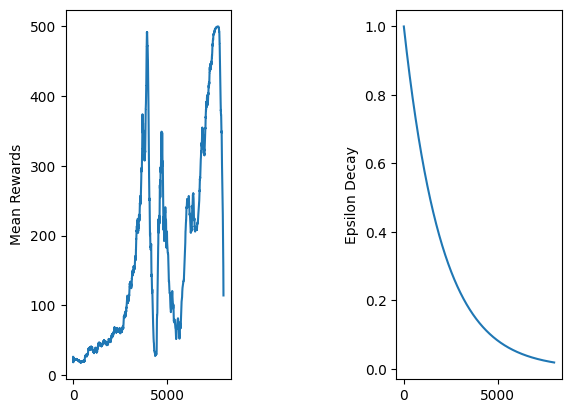

In [ ]:
# 5.训练

def train_cartpole1():
    dq= Agent(hyperparameter_set='cartpole1')
    print("开始训练 cartpole1")
    dq.run(is_training=True)
    return dq
dq = train_cartpole1()

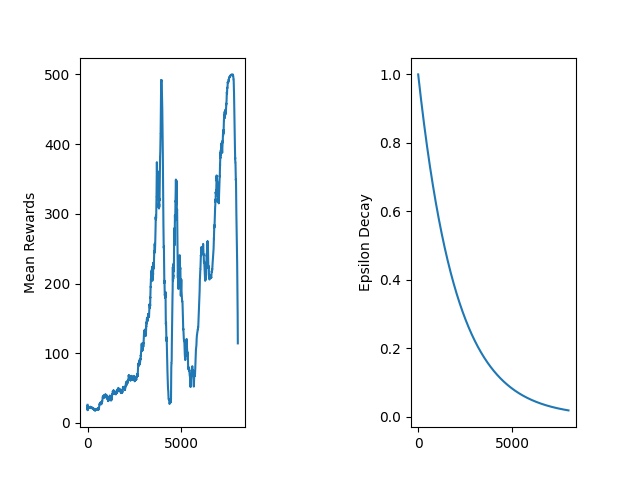

In [ ]:
from IPython.display import Image
Image('runs/cartpole1.png')

In [ ]:
# 6.定义测试函数

def test_cartpole1(dq):
    print(torch.cuda.is_available())
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model_path = "runs/cartpole1.pt"

    env = gym.make("CartPole-v1", render_mode="rgb_array")

    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n
    hidden_dim = 128

    # q_net = DQN(state_dim, action_dim, hidden_dim=hidden_dim, enable_dueling_dqn=False).to(device)

    # try:
    #     try:
    #         sd = torch.load(model_path, map_location=device, weights_only=True)
    #     except TypeError:
    #         sd = torch.load(model_path, map_location=device)
    #     q_net.load_state_dict(sd)
    #     print("成功加载训练好的模型：", model_path)
    # except FileNotFoundError:
    #     print(f"模型文件 '{model_path}' 未找到，请先运行 train() 进行训练")
    #     env.close()
    #     return
    q_net=dq.dqn
    q_net.load_state_dict(torch.load(dq.MODEL_FILE, map_location=device))
    q_net.eval()

    all_frames = []
    downsample = 2

    for ep in range(3):
        state, _ = env.reset()
        total_reward = 0.0
        terminated = truncated = False
        step = 0

        while not (terminated or truncated):
            if step % downsample == 0:
                frame = env.render()
                if frame is not None:
                    all_frames.append(frame)

            with torch.no_grad():
                state_tensor = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
                action = int(q_net(state_tensor).argmax(dim=1).item())

            state, reward, terminated, truncated, _ = env.step(action)
            total_reward += float(reward)
            step += 1

        print(f"测试回合 {ep+1}, 总奖励: {total_reward:.1f}")

    env.close()

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.axis("off")
    img = ax.imshow(all_frames[0])

    def update(frame):
        img.set_data(frame)
        return [img]

    anim = animation.FuncAnimation(
        fig=fig, func=update, frames=all_frames,
        interval=50, blit=True, repeat=False
    )

    plt.close(fig)
    return HTML(anim.to_jshtml())


In [ ]:
# 7.测试
test_cartpole1(dq)

True
测试回合 1, 总奖励: 500.0
测试回合 2, 总奖励: 500.0
测试回合 3, 总奖励: 500.0
